In [3]:
import os
import sys
import pandas as pd
import numpy as np

# Add the project root to Python's path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.load_data import load_data

df = load_data()

print(df.shape)

(1067371, 8)


In [16]:
import os
import sys

# Add the project root to Python's path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.load_data import load_data

df = load_data()

print(df.shape)
df.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [18]:
# Find the last transaction date in the dataset
snapshot_date = df["InvoiceDate"].max()

print("Last transaction date:", snapshot_date)

# Customer's last purchase date
last_purchase = (
    df.groupby("Customer ID")["InvoiceDate"]
      .max()
      .reset_index()
)

# Calculate Recency (days since last purchase)
last_purchase["Recency"] = (
    snapshot_date - last_purchase["InvoiceDate"]
).dt.days

# Create Churn column
last_purchase["Churn"] = (
    last_purchase["Recency"] > 90
).astype(int)

# Display first few rows
last_purchase.head()

Last transaction date: 2011-12-09 12:50:00


,Customer ID,InvoiceDate,Recency,Churn
0,12346.0,2011-01-18 10:17:00,325,1
1,12347.0,2011-12-07 15:52:00,1,0
2,12348.0,2011-09-25 13:13:00,74,0
3,12349.0,2011-11-21 09:51:00,18,0
4,12350.0,2011-02-02 16:01:00,309,1


In [29]:
import os

print(os.getcwd())

c:\Users\ADMIN\OneDrive\Documents\GitHub\Customer-behavior-prediction\notebooks


In [30]:
# Load customer-level features
customer_features = pd.read_csv("../data/processed/customer_features.csv")

# Merge with churn labels
model_data = customer_features.merge(
    last_purchase[["Customer ID", "Churn"]],
    on="Customer ID",
    how="left"
)

# Check the result
print(model_data.shape)
model_data.head()

(5942, 8)


,Customer ID,TotalOrders,TotalProducts,AverageOrderValue,Recency,Frequency,Monetary,Churn
0,12346.0,17,52,-1.347500,326,17,-64.68,1
1,12347.0,8,3286,22.266087,2,8,5633.32,0
2,12348.0,5,2714,39.596078,75,5,2019.40,0
3,12349.0,5,1619,24.469667,19,5,4404.54,0
4,12350.0,1,197,19.670588,310,1,334.40,1


In [31]:
customer_features = pd.read_csv("../data/processed/customer_features.csv")

print(customer_features.shape)
customer_features.head()

(5942, 7)


,Customer ID,TotalOrders,TotalProducts,AverageOrderValue,Recency,Frequency,Monetary
0,12346.0,17,52,-1.347500,326,17,-64.68
1,12347.0,8,3286,22.266087,2,8,5633.32
2,12348.0,5,2714,39.596078,75,5,2019.40
3,12349.0,5,1619,24.469667,19,5,4404.54
4,12350.0,1,197,19.670588,310,1,334.40


In [32]:
# Merge customer features with churn labels
model_data = customer_features.merge(
    last_purchase[["Customer ID", "Churn"]],
    on="Customer ID",
    how="left"
)

# Check the merged dataset
print(model_data.shape)
model_data.head()

(5942, 8)


,Customer ID,TotalOrders,TotalProducts,AverageOrderValue,Recency,Frequency,Monetary,Churn
0,12346.0,17,52,-1.347500,326,17,-64.68,1
1,12347.0,8,3286,22.266087,2,8,5633.32,0
2,12348.0,5,2714,39.596078,75,5,2019.40,0
3,12349.0,5,1619,24.469667,19,5,4404.54,0
4,12350.0,1,197,19.670588,310,1,334.40,1


In [33]:
# Check class balance
print(model_data["Churn"].value_counts())

print("\nPercentage:")

print(model_data["Churn"].value_counts(normalize=True) * 100)

Churn
1    3020
0    2922
Name: count, dtype: int64

Percentage:
Churn
1    50.824638
0    49.175362
Name: proportion, dtype: float64


In [43]:
from sklearn.model_selection import train_test_split

# Features (X)
X = model_data.drop(columns=["Customer ID", "Churn", "Recency"])

# Target (y)
y = model_data["Churn"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (4753, 5)
Testing set : (1189, 5)


In [44]:
from sklearn.linear_model import LogisticRegression

# Create the model
log_model = LogisticRegression(max_iter=1000)

# Train the model
log_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.6871320437342304
Precision: 0.646095717884131
Recall   : 0.8493377483443708
F1 Score : 0.7339055793991416
ROC-AUC  : 0.7615809135676685

Confusion Matrix
[[304 281]
 [ 91 513]]

Classification Report
              precision    recall  f1-score   support

           0       0.77      0.52      0.62       585
           1       0.65      0.85      0.73       604

    accuracy                           0.69      1189
   macro avg       0.71      0.68      0.68      1189
weighted avg       0.71      0.69      0.68      1189



In [46]:
from sklearn.tree import DecisionTreeClassifier

In [47]:
# Create the model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [48]:
# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Predict probabilities (needed for ROC-AUC)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.6005046257359126
Precision: 0.6087689713322091
Recall   : 0.597682119205298
F1 Score : 0.6031746031746031
ROC-AUC  : 0.6015721401482991

Confusion Matrix
[[353 232]
 [243 361]]

Classification Report
              precision    recall  f1-score   support

           0       0.59      0.60      0.60       585
           1       0.61      0.60      0.60       604

    accuracy                           0.60      1189
   macro avg       0.60      0.60      0.60      1189
weighted avg       0.60      0.60      0.60      1189



In [49]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [51]:
# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Predict probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.671152228763667
Precision: 0.6789915966386555
Recall   : 0.6688741721854304
F1 Score : 0.6738949124270225
ROC-AUC  : 0.7378983415407258

Confusion Matrix
[[394 191]
 [200 404]]

Classification Report
              precision    recall  f1-score   support

           0       0.66      0.67      0.67       585
           1       0.68      0.67      0.67       604

    accuracy                           0.67      1189
   macro avg       0.67      0.67      0.67      1189
weighted avg       0.67      0.67      0.67      1189



In [52]:
# Model Comparison Table

import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.6871,
        0.6005,
        0.6712
    ],
    "Precision": [
        0.6461,
        0.6088,
        0.6790
    ],
    "Recall": [
        0.8493,
        0.5977,
        0.6689
    ],
    "F1 Score": [
        0.7339,
        0.6032,
        0.6739
    ],
    "ROC-AUC": [
        0.7616,
        0.6016,
        0.7379
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6871,0.6461,0.8493,0.7339,0.7616
1,Decision Tree,0.6005,0.6088,0.5977,0.6032,0.6016
2,Random Forest,0.6712,0.6790,0.6689,0.6739,0.7379


In [53]:
comparison.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)

print("Model comparison table saved successfully!")

Model comparison table saved successfully!


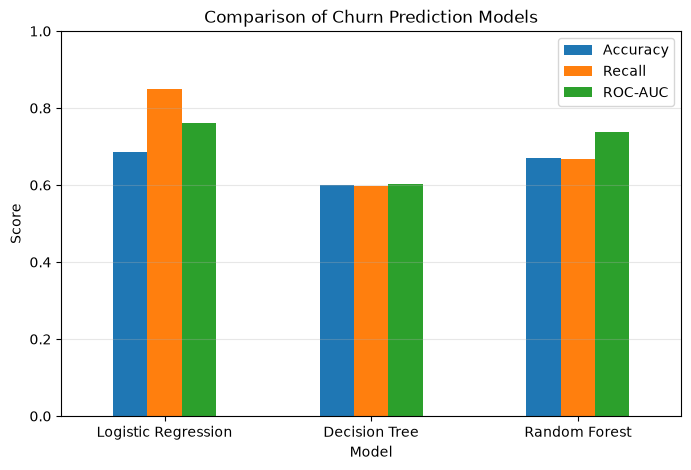

Chart saved successfully!


In [56]:
import matplotlib.pyplot as plt

comparison.plot(
    x="Model",
    y=["Accuracy", "Recall", "ROC-AUC"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Comparison of Churn Prediction Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

# Save the figure
plt.savefig(
    "../data/processed/model_comparison_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully!")